In [ ]:
"""
Pre-Modeling Statistical Diagnostic Suite for EEG Features.
Evaluates Normality, Separability (Parametric & Non-Parametric), Effect Size, and Multicollinearity.
"""

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =====================================================================
# 1. Load Data
# =====================================================================
df = pd.read_csv('plrx.txt', delimiter='\t', header=None)
X = df.iloc[:, :12]
y = df.iloc[:, 12]

feature_names = [f'c{i+1}' for i in range(12)]
X.columns = feature_names

# Separate the two classes for comparison
class_1 = X[y == 1.0]  # Relaxed
class_2 = X[y == 2.0]  #

In [15]:
# Helper function for Cohen's d
def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    var1, var2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    return (np.mean(g1) - np.mean(g2)) / np.sqrt(pooled_var)

# =====================================================================
# 2. Normality & Separability Tests
# =====================================================================
results = []

for col in feature_names:
    g1, g2 = class_1[col], class_2[col]
    
    # 1. Normality Test (Shapiro-Wilk) on the whole feature
    stat_sw, p_sw = stats.shapiro(X[col])
    is_normal = p_sw > 0.05
    
    # 2. Parametric Separability (Welch's t-test)
    stat_t, p_t = stats.ttest_ind(g1, g2, equal_var=False)
    
    # 3. Non-Parametric Separability (Mann-Whitney U)
    stat_mw, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    
    # 4. Effect Size (Cohen's d)
    d_val = cohens_d(g1, g2)
    
    results.append({
        'Feature': col,
        'Normal?': is_normal,
        'p_sw': p_sw,
        'Shapiro p-val': p_sw,
        'Welch t p-val': p_t,
        'Mann-Whitney p-val': p_mw,
        "Cohen's d": abs(d_val)
    })

results_df = pd.DataFrame(results)

print("="*85)
print("FEATURE NORMALITY AND SEPARABILITY")
print("="*85)
# Print rounded to 4 decimal places for clean reading
print(results_df.round(4).to_string(index=False))

# =====================================================================
# 3. Multicollinearity (VIF)
# =====================================================================
# VIF requires a constant (intercept) column to calculate properly
X_with_const = sm.add_constant(X)

vif_data = []
for i in range(1, X_with_const.shape[1]): # Skip the constant column
    vif_val = variance_inflation_factor(X_with_const.values, i)
    vif_data.append({
        'Feature': feature_names[i-1],
        'VIF': vif_val
    })

vif_df = pd.DataFrame(vif_data)

print("\n" + "="*85)
print("MULTICOLLINEARITY (VARIANCE INFLATION FACTOR)")
print("="*85)
print("Rule of thumb: VIF > 5 indicates high redundancy; VIF > 10 is severe.")
print("-" * 85)
print(vif_df.round(2).sort_values(by='VIF', ascending=False).to_string(index=False))

# =====================================================================
# 4. Summary Interpretation
# =====================================================================
print("\n" + "="*85)
print("AUTOMATED DIAGNOSTIC SUMMARY")
print("="*85)

non_normal = results_df[~results_df['Normal?']]['Feature'].tolist()
print(f"1. Non-Normal Features: {len(non_normal)}/12 fail the normality assumption.")

significant_mw = results_df[results_df['Mann-Whitney p-val'] < 0.05]['Feature'].tolist()
print(f"2. Significant Separability: Only {len(significant_mw)}/12 features have p < 0.05 (Mann-Whitney).")

meaningful_effect = results_df[results_df["Cohen's d"] > 0.5]['Feature'].tolist()
print(f"3. Meaningful Effect Size (d > 0.5): Only {len(meaningful_effect)}/12 features.")

severe_vif = vif_df[vif_df['VIF'] > 10]['Feature'].tolist()
print(f"4. Severe Multicollinearity (VIF > 10): {len(severe_vif)} features are highly redundant.")

FEATURE NORMALITY AND SEPARABILITY
Feature  Normal?   p_sw  Shapiro p-val  Welch t p-val  Mann-Whitney p-val  Cohen's d
     c1    False 0.0017         0.0017         0.6356              0.4344     0.0683
     c2     True 0.1750         0.1750         0.8094              1.0000     0.0374
     c3     True 0.7712         0.7712         0.8932              0.9565     0.0218
     c4     True 0.4720         0.4720         0.5016              0.5645     0.1139
     c5     True 0.0914         0.0914         0.5277              0.5447     0.1028
     c6     True 0.3378         0.3378         0.6100              0.6662     0.0798
     c7     True 0.0977         0.0977         0.5407              0.4454     0.0951
     c8     True 0.6474         0.6474         0.9710              0.9516     0.0061
     c9    False 0.0347         0.0347         0.4472              0.4464     0.1203
    c10    False 0.0001         0.0001         0.6275              0.9752     0.0858
    c11    False 0.0045       

Generating pairplot... (This may take a few seconds for a 12x12 grid)


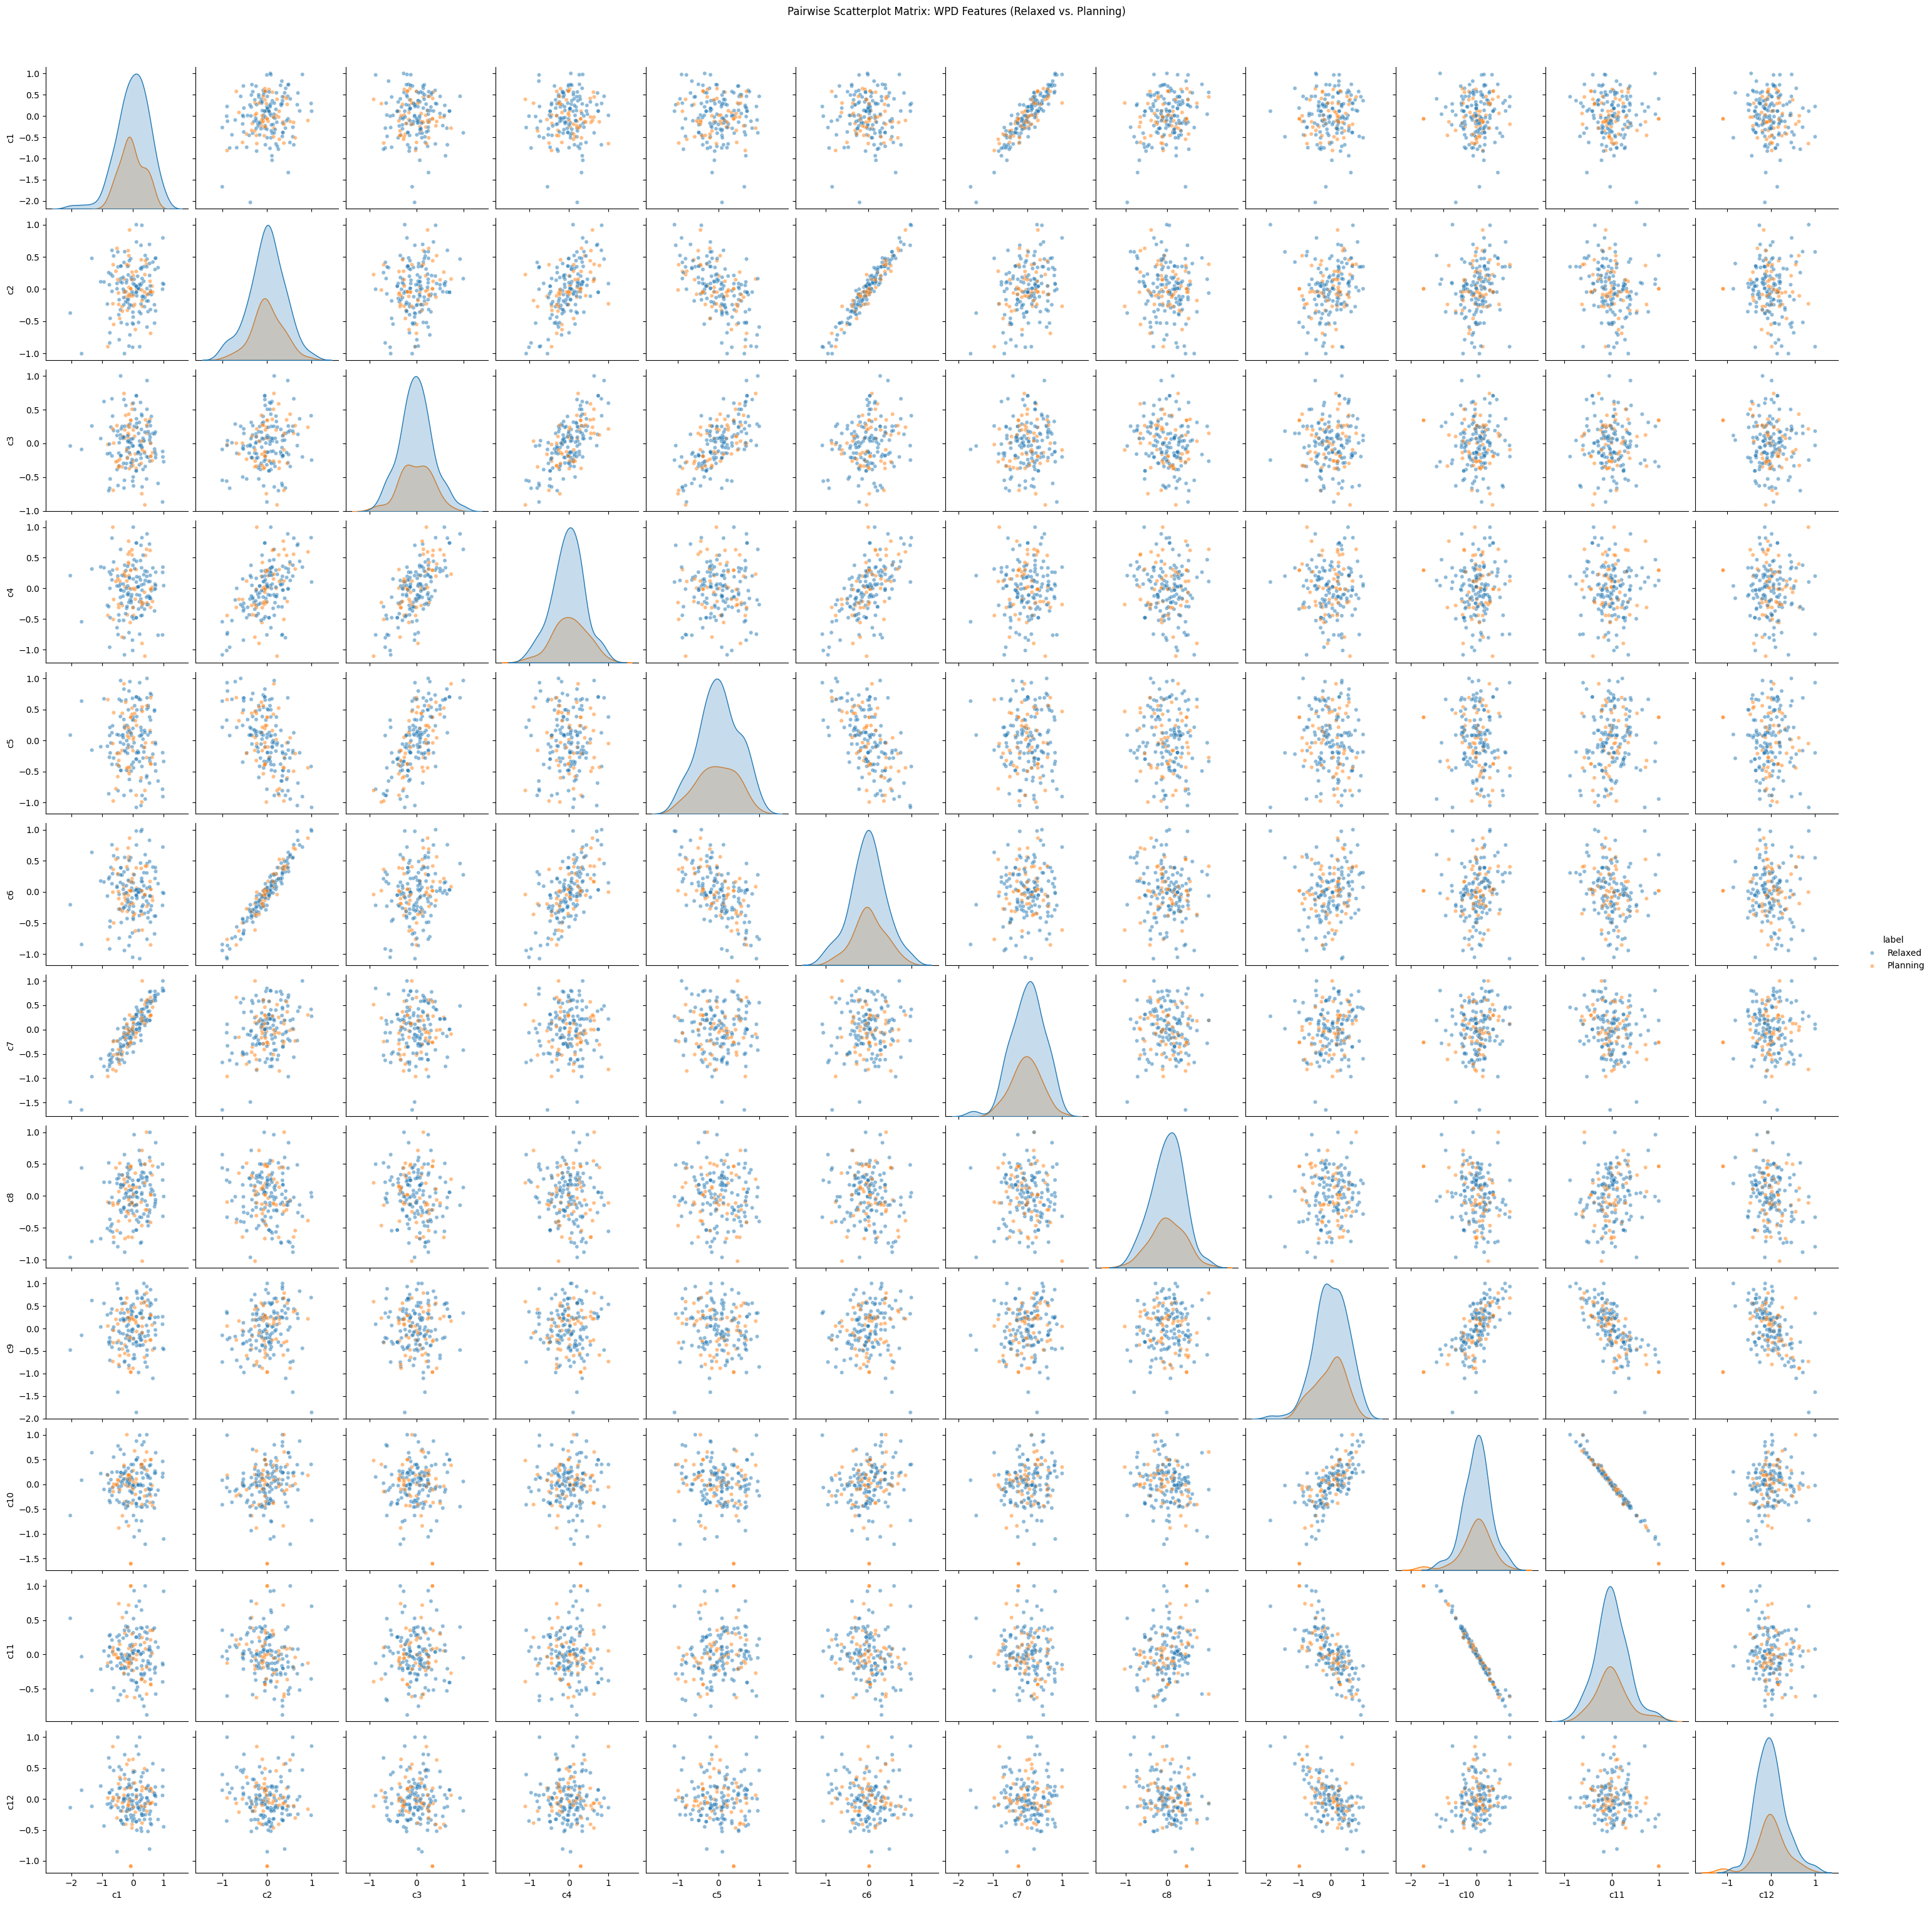

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================================
# 1. Load the dataset and assign column names
# =====================================================================
df = pd.read_csv('plrx.txt', delimiter='\t', header=None).iloc[:, :13]

# Name the 12 feature columns and the label column
feature_names = [f'c{i+1}' for i in range(12)]
df.columns = feature_names + ['label']

# =====================================================================
# 2. Format labels for a cleaner legend
# =====================================================================
df['label'] = df['label'].map({1.0: 'Relaxed', 2.0: 'Planning'})

# =====================================================================
# 3. Generate the Pairplot
# =====================================================================
print("Generating pairplot... (This may take a few seconds for a 12x12 grid)")

# hue='label' colors the points by class
# diag_kind='kde' replaces the diagonal scatterplots with density curves
# plot_kws={'alpha': 0.5} makes points semi-transparent to reveal heavy overlapping
g = sns.pairplot(
    df, 
    hue='label', 
    palette={'Relaxed': '#1f77b4', 'Planning': '#ff7f0e'},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20} # 's' controls point size
)

g.fig.suptitle('Pairwise Scatterplot Matrix: WPD Features (Relaxed vs. Planning)', y=1.02)

# Save to a high-resolution file so you can zoom in, then display it
plt.savefig('eeg_pairplot_full.png', dpi=300, bbox_inches='tight')
plt.show()